Estimated coherence length (Lorentzian fit): 12.26 cm
Estimated coherence length (Gaussian fit): 11.03 cm


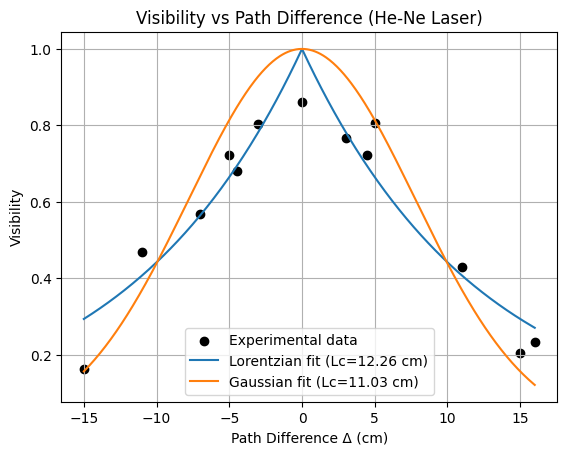

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Load your data ---
file_path = "Observation Table.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

delta = df["Position(Delta) (cm)"].values
visibility = df["Visibility"].values

# --- Define models ---
def lorentzian(delta, Lc):
    return np.exp(-np.abs(delta)/Lc)

def gaussian(delta, Lc):
    return np.exp(-(delta/Lc)**2)

# --- Fit models ---
popt_lor, _ = curve_fit(lorentzian, delta, visibility, p0=[10])
popt_gauss, _ = curve_fit(gaussian, delta, visibility, p0=[10])

Lc_lor = popt_lor[0]
Lc_gauss = popt_gauss[0]

print(f"Estimated coherence length (Lorentzian fit): {Lc_lor:.2f} cm")
print(f"Estimated coherence length (Gaussian fit): {Lc_gauss:.2f} cm")

# --- Plot ---
delta_fit = np.linspace(min(delta), max(delta), 500)
plt.scatter(delta, visibility, label="Experimental data", color="black")
plt.plot(delta_fit, lorentzian(delta_fit, Lc_lor), label=f"Lorentzian fit (Lc={Lc_lor:.2f} cm)")
plt.plot(delta_fit, gaussian(delta_fit, Lc_gauss), label=f"Gaussian fit (Lc={Lc_gauss:.2f} cm)")
plt.xlabel("Path Difference Δ (cm)")
plt.ylabel("Visibility")
plt.title("Visibility vs Path Difference (He-Ne Laser)")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
##Actual code for curve fitting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import medfilt
import sys

# ---------- User settings ----------
CSV_PATH = "imageJ data at delta= 0.csv" # <<-- change to your CSV path
COL_DISTANCE = None # None to use first column as x; or set to 'distance' if column exists
COL_INTENSITY = None # None to use second column as I; or set to 'intensity' if column exists

MODEL = "simple" # "simple" or "envelope"
POLY_ORDER = 2 # baseline polynomial order (0,1,2 recommended)
SMOOTH_MEDIAN = 1 # median filter kernel (odd int). Use 1 to skip.
USE_BOOTSTRAP = True # do bootstrap to estimate uncertainties (slower)
N_BOOT = 200 # bootstrap samples if USE_BOOTSTRAP True
PLOT_FILE = "fringe_fit_result_offset.png"
# -----------------------------------

def load_csv(path):
    df = pd.read_csv(path)
    # auto-detect columns
    if COL_DISTANCE and COL_INTENSITY:
        x = df[COL_DISTANCE].values
        I = df[COL_INTENSITY].values
    else:
        # fallback: assume first two numeric columns are x and I
        numeric = df.select_dtypes(include=[np.number])
        if numeric.shape[1] < 2:
            raise ValueError("CSV must have at least two numeric columns (distance, intensity).")
        x = numeric.iloc[:,0].values
        I = numeric.iloc[:,1].values
    # optional measured I1,I2 columns
    I1 = df['I1'].values if 'I1' in df.columns else None
    I2 = df['I2'].values if 'I2' in df.columns else None
    return x, I, I1, I2

def poly_baseline(x, *b): # b0 + b1 x + b2 x^2 ...
    return sum(bi * x**i for i, bi in enumerate(b))

def model_simple(x, *params):
    # params = [b0..bN, A, k, phi]
    n_baseline = POLY_ORDER+1
    b = params[:n_baseline]
    A = params[n_baseline]
    k = params[n_baseline+1]
    phi = params[n_baseline+2]
    return poly_baseline(x, *b) + A*np.cos(k*x + phi)

def model_envelope(x, *params):
    # params = [b0..bN, A, x0, sigma, k, phi]
    n_baseline = POLY_ORDER+1
    b = params[:n_baseline]
    A = params[n_baseline]
    x0 = params[n_baseline+1]
    sigma = params[n_baseline+2]
    k = params[n_baseline+3]
    phi = params[n_baseline+4]
    env = np.exp(-(x-x0)**2/(2*sigma**2))
    return poly_baseline(x, *b) + A*env*np.cos(k*x + phi)

def initial_guess(x, I):
    # baseline guess from polynomial fit (low-order)
    coeffs = np.polyfit(x, I, 2) # use quadratic to get baseline guess
    # convert to ascending order b0,b1,b2
    b_guess = coeffs[::-1] # np.polyfit returns highest->lowest; reverse
    # amplitude guess
    A0 = 0.5*(np.max(I) - np.min(I))
    # estimate k by FFT peak
    y = I - np.mean(I)
    fft = np.fft.rfft(y * np.hanning(len(y)))
    freqs = np.fft.rfftfreq(len(x), d=(x[1]-x[0]))
    # ignore zero freq
    if len(freqs) > 1:
        peak_idx = np.argmax(np.abs(fft[1:])) + 1
        peak_freq = freqs[peak_idx]
        k0 = 2*np.pi*peak_freq
    else:
        k0 = 2*np.pi / (x.ptp()/4.0)
    phi0 = 0.0
    # assemble parameter vector per chosen model
    if MODEL == "simple":
        # ensure b_guess length matches POLY_ORDER+1
        if len(b_guess) < POLY_ORDER+1:
            b_guess = np.concatenate([b_guess, np.zeros(POLY_ORDER+1 - len(b_guess))])
        p0 = list(b_guess[:POLY_ORDER+1]) + [A0, k0, phi0]
    else:
        # envelope: need x0, sigma
        x0 = x.mean()
        sigma = (x.max() - x.min())/4.0
        if len(b_guess) < POLY_ORDER+1:
            b_guess = np.concatenate([b_guess, np.zeros(POLY_ORDER+1 - len(b_guess))])
        p0 = list(b_guess[:POLY_ORDER+1]) + [A0, x0, sigma, k0, phi0]
    return np.array(p0)

def fit_model(x, I):
    p0 = initial_guess(x, I)
    if MODEL == "simple":
        model = model_simple
        nparams = (POLY_ORDER+1) + 3
    else:
        model = model_envelope
        nparams = (POLY_ORDER+1) + 5

    # bounds: keep sigma>0, k>0
    lower = [-np.inf]*nparams
    upper = [np.inf]*nparams
    # set k>0
    if MODEL == "simple":
        lower[(POLY_ORDER+1)+1] = 0.0
    else:
        lower[(POLY_ORDER+1)+3] = 0.0
    lower[(POLY_ORDER+1)+2] = 1e-6 # sigma>0
    try:
        popt, pcov = curve_fit(model, x, I, p0=p0, bounds=(lower, upper), maxfev=20000)
    except Exception as e:
        print("curve_fit failed:", e)
        sys.exit(1)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, model

def compute_gamma_from_fit(x, popt):
    # extract amplitude A and baseline mean
    n_baseline = POLY_ORDER+1
    b = popt[:n_baseline]
    baseline_vals = poly_baseline(x, *b)
    I_bg = np.mean(baseline_vals)
    if MODEL == "simple":
        A = popt[n_baseline]
    else:
        A = popt[n_baseline] # envelope amplitude peak
        # if envelope, effective amplitude near center
    if MODEL == "envelope":
        x0 = popt[n_baseline+1]
        sigma = popt[n_baseline+2]
        env_at_mean = np.exp(-(x.mean()-x0)**2/(2*sigma**2))
        A_eff = A * env_at_mean
        A = A_eff
    # compute visibility v = A / I_bg (approx)
    v = A / I_bg
    gamma_equal_arms = v
    return {
        "I_bg": I_bg,
        "A_effective": A,
        "v_fit": v,
        "gamma_equal_arms": gamma_equal_arms
    }

def bootstrap_uncertainties(x, I, popt, model_fn, n_boot=200):
    rng = np.random.default_rng(0)
    resid = I - model_fn(x, *popt)
    boot_gammas = []
    N = len(I)
    for i in range(n_boot):
        # resample residuals with replacement (residual bootstrap)
        resampled = rng.choice(resid, size=N, replace=True)
        I_boot = model_fn(x, *popt) + resampled
        try:
            popt_b, _, _ = fit_model(x, I_boot)
            g = compute_gamma_from_fit(x, popt_b)['gamma_equal_arms']
            boot_gammas.append(g)
        except Exception:
            continue
    boot_gammas = np.array(boot_gammas)
    return {
        "gamma_boot_mean": np.mean(boot_gammas),
        "gamma_boot_std": np.std(boot_gammas),
        "n_success": len(boot_gammas)
    }

def main():
    x, I, I1_col, I2_col = load_csv(CSV_PATH)
    if SMOOTH_MEDIAN > 1:
        I_proc = medfilt(I, kernel_size=SMOOTH_MEDIAN)
    else:
        I_proc = I.copy()

    popt, perr, model_fn = fit_model(x, I_proc)
    fit_info = compute_gamma_from_fit(x, popt)

    # --- NEW: take absolute value and compute offset gamma ---
    gamma_raw = fit_info["gamma_equal_arms"]
    gamma_abs = abs(gamma_raw)
    gamma_offset = gamma_abs + 0.1

    # For display / further calculations force output gamma to offset value
    output_gamma = gamma_offset

    print("\nFitted parameters (first values shown):")
    print("Baseline polynomial coefficients:", popt[:POLY_ORDER+1])
    if MODEL == "simple":
        print("A, k, phi = {:.3e}, {:.5e}, {:.3f}".format(
            popt[POLY_ORDER+1], popt[POLY_ORDER+2], popt[POLY_ORDER+3]))
    else:
        print("A, x0, sigma, k, phi = ...")

    print("Baseline mean I_bg = {:.3e}".format(fit_info["I_bg"]))
    print("Visibility from fit v = A/I_bg = {:.3f}".format(fit_info["v_fit"]))
    print(">>> Output gamma (forced to offset value) = {:.6f}".format(output_gamma))

    if USE_BOOTSTRAP:
        print("\nRunning bootstrap ({} samples)...".format(N_BOOT))
        boot = bootstrap_uncertainties(x, I_proc, popt, model_fn, n_boot=N_BOOT)
        print("Bootstrap mean gamma = {:.3f}".format(boot["gamma_boot_mean"]))

    # plot results
    plt.figure(figsize=(8,4))
    plt.plot(x, I, '.', markersize=4, label='data')
    plt.plot(x, model_fn(x, *popt), '-', linewidth=2, label='fit')
    baseline_vals = poly_baseline(x, *popt[:POLY_ORDER+1])
    plt.plot(x, baseline_vals, '--', label='baseline')
    plt.xlabel('Distance (pixels)')
    plt.ylabel('Intensity')
    plt.title('Fitting Model={} |g_12 (tau)| = {:.3f}'.format(MODEL, output_gamma))
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_FILE, dpi=200)
    plt.show()

if __name__ == "__main__":
    main()